In [ ]:
import os
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import pearsonr, spearmanr
from mpl_toolkits.axes_grid1 import make_axes_locatable
import numpy as np

def plot_rpkm_hexbin(pred_results_path, upstream=100000, downstream=90000, stride=2, 
                     outdir="pdf_regression", outpdf=None):
    
    os.makedirs(outdir, exist_ok=True)
    
    if outpdf is None:
        outpdf = f"{outdir}/rpkm_hexbin_regression_up{upstream}_down{downstream}_stride{stride}.pdf"
    
    # CSV読み込み
    df_pred = pd.read_csv(pred_results_path)

    xcol, ycol = 'True_RPKM', 'Predicted_RPKM'

    # ---- Figure & Axes manually created (better control) ----
    fig, ax = plt.subplots(figsize=(5, 5))

    # Hexbin
    hb = ax.hexbin(
        df_pred[xcol], df_pred[ycol],
        gridsize=50,
        cmap="coolwarm",
        mincnt=1,
        bins='log'
    )

    # Square-ish aspect
    try:
        ax.set_box_aspect(1)
    except:
        ax.set_aspect('equal', 'box')

    # Axis limits
    maxv = float(max(df_pred[xcol].max(), df_pred[ycol].max()))
    ax.set_xlim(-0.5, maxv + 0.5)
    ax.set_ylim(-0.5, 6.8)

    xmin, xmax = ax.get_xlim()
    ax.set_xticks(np.arange(int(xmin), int(xmax) + 1, 2))

    # Labels & title
    ax.set_title("Gene Expression Prediction (RPKM)")
    ax.set_xlabel("log(RPKM) observed")
    ax.set_ylabel("log(RPKM) predicted")

    # ---- Tight narrow colorbar ----
    # cbar = fig.colorbar(
    #     hb, ax=ax,
    #     fraction=0.035,  # narrow bar
    #     pad=0.02         # close to panel
    # )

    # --- Create a perfectly aligned colorbar ---
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.1)  # ← thin and aligned
    cbar = fig.colorbar(hb, cax=cax, shrink=0.8)

    # # ---- Stats text INSIDE axes, so no widening of canvas ----
    # n = len(df_pred)
    # pearson_r, pearson_p = pearsonr(df_pred[xcol], df_pred[ycol])
    # spearman_rho, spearman_p = spearmanr(df_pred[xcol], df_pred[ycol])

    # text = (
    #     f"up{upstream}_down{downstream}_stride{stride}\n"
    #     f"n = {n}\n"
    #     f"Pearson r = {pearson_r:.3f} (p={pearson_p:.1e})\n"
    #     f"Spearman ρ = {spearman_rho:.3f} (p={spearman_p:.1e})"
    # )

    # # inside upper-right corner
    # ax.text(
    #     0.98, 0.98, text,
    #     transform=ax.transAxes,
    #     ha="right", va="top",
    #     fontsize=9,
    #     bbox=dict(boxstyle="round", facecolor="white", alpha=0.7, edgecolor="none")
    # )

    # Layout & save
    fig.tight_layout()
    fig.savefig(outpdf, dpi=300, bbox_inches="tight")
    print(f"Saved figure as {outpdf}")
    plt.show()


Saved figure as pdf_regression/rpkm_hexbin_regression_up100000_down90000_stride2.pdf


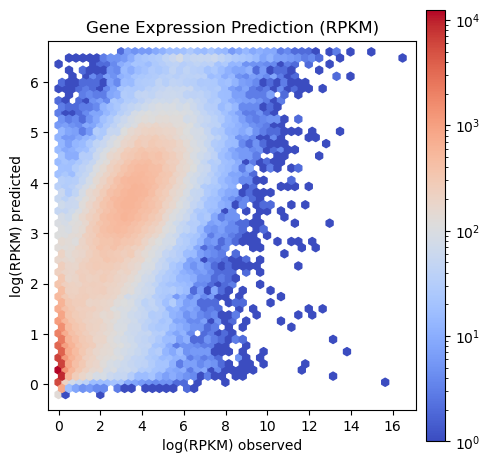

In [50]:
upstream = 100000
downstream = 90000
stride = 2

#results_dir = f'/work3/Projects/Project_ChromBERT/jsakatsume/prom_longer_finetune_v2'
results_dir = f'../revision_temp/prom_longer_finetune_v2'

pred_results = f'{results_dir}/predict_result/regression_up{upstream}_down{downstream}_stride{stride}/pred_results.csv'
plot_rpkm_hexbin(pred_results, upstream=upstream, downstream=downstream, stride=stride)
